In [1]:
import numpy as np
from scipy.special import factorial
from scipy.stats import binned_statistic

In [2]:
import matplotlib.pyplot as plt

In [3]:
import scipy as sp

In [4]:
import sys
sys.path.append(r"C:/Users/xylin/Documents/Researches/multiphonon-direct-detection/StructureFactor1D.py")
from StructureFactor1D import StructureFactor1D

In [5]:
class RateCalculations:
    def __init__(self, mass_DM, q_val, omega_list,omega_threshold,s_factor,cross_section):
        c = 2.998e5 #in km/s
        self.mass_DM = mass_DM
        self.mass_proton = 938.272e3 # keV
        self.density_DM = 0.3e6 # keV/cm^3, plus minus 0.1
        self.density_target = 1.307e30 # keV/cm^3 from silicon density of 2329.6 kg/m3
        self.v_esc = 500/c 
        self.v_earth = 240/c 
        self.v_disp = 220/c
        self.q_val = q_val
        self.omega_list = omega_list 
        self.s_factor = s_factor
        self.omega_threshold = omega_threshold # detector threshold. keV
        self.cross_section = cross_section # cm^2
        self.v_max = self.v_esc + self.v_earth 
        self.num_density = 2.15e25 # per kg
        # unit conversion, ref: https://physics.nist.gov/cuu/Constants/energy.html
        self.keV2InvS = 2.418e17 # keV to 1/s
        self.year2sec = 86400. * 365.
        self.keV2InvYr = self.keV2InvS * self.year2sec
        self.keV2kg = 1.78e-33
        self.keV2InvCm = 8.065e6

    def get_v_min(self, mass_DM, q,):
        return self.omega_list/ q + q / (2 * mass_DM)
    
    def _inverse_mean_sol1(self, v_min):
        '''
        Helper function used in get_inverse_mean_func
        '''
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2*ratio*np.exp(-ratio**2)) # 1904.07915 eqn 108
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf((v_min+self.v_earth)/self.v_disp) 
                                                       - sp.special.erf((v_min-self.v_earth)/self.v_disp))
                        - 4 * self.v_earth * np.exp(-ratio**2))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral 

    def _inverse_mean_sol2(self,v_min): 
        '''
        Helper function used in get_inverse_mean_func
        '''
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2*ratio*np.exp(-ratio**2))
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf(ratio) 
                                                       - sp.special.erf((v_min-self.v_earth)/self.v_disp))
                        - 2 * (self.v_esc-v_min+self.v_earth) * np.exp(-ratio**2 ))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral


    def get_inverse_mean_func(self,mass_DM, q,): # 1509.01598 appendix B
        '''
        returns: inverse mean function, 3d array with the same shape as v_min (num of DM mass, num of p, num of omega)
        '''
        v_min = self.get_v_min(mass_DM, q)
        return np.where(v_min>(self.v_esc+self.v_earth), 0., 
                        np.where(v_min<(self.v_esc-self.v_earth),
                                self._inverse_mean_sol1(v_min),
                                self._inverse_mean_sol2(v_min)))
    
    
    def _get_omega_mask(self,):
        omega_max = self.q_val * self.v_max - self.q_val**2 / (2 * self.mass_DM)
        return (self.omega_list > self.omega_threshold) & (self.omega_list < omega_max)

    
    def get_diff_rate_dRdq(self, ): # 2108.03239 eqn 11
        reducedMass = self.mass_DM * self.mass_proton/(self.mass_DM + self.mass_proton)
        constFactor = self.density_DM * self.cross_section / (4* np.pi * self.density_target * self.mass_DM * reducedMass**2)
        omega_mask = self._get_omega_mask()
        if np.sum(omega_mask)<2: 
            return 0.
        else:
            integrand = self.get_inverse_mean_func(self.mass_DM,self.q_val) * self.s_factor * self.q_val
            return constFactor * sp.integrate.simpson(integrand[omega_mask], self.omega_list[omega_mask]) * self.keV2InvCm**2 * self.keV2InvYr / self.keV2kg # per kg-year-keV
    
    def get_v_min_nr(self):
        reducedMass = self.mass_DM * self.mass_proton*28/(self.mass_DM + self.mass_proton*28)
        return np.sqrt(28*self.mass_proton * self.omega_list / (2*reducedMass))
        
    def get_inverse_mean_func_nr(self,): # 1509.01598 appendix B
        '''
        returns: inverse mean function, 3d array with the same shape as v_min (num of DM mass, num of p, num of omega)
        '''
        v_min = self.get_v_min_nr()
        return np.where(v_min>(self.v_esc+self.v_earth), 0., 
                        np.where(v_min<(self.v_esc-self.v_earth),
                                self._inverse_mean_sol1(v_min),
                                self._inverse_mean_sol2(v_min)))

    def get_nr_diff_rate_dRdq(self):
        reducedMass = self.mass_DM * self.mass_proton*28/(self.mass_DM + self.mass_proton*28)
        return self.num_density * (self.density_DM / self.mass_DM) * (self.cross_section*(self.mass_proton*28)/(2*reducedMass**2)) * 28**2 * self.get_inverse_mean_func_nr()

In [6]:
def get_q_lim(mass_DM, omega_threshold=10e-6):
    v_max = 0.00247 # in c
    q_min = mass_DM * v_max * (1 - np.sqrt(1-2*omega_threshold/(mass_DM * (v_max**2))))
    q_max = mass_DM * v_max * (1 + np.sqrt(1-2*omega_threshold/(mass_DM * (v_max**2))))
    return  q_min, q_max

def get_omega_lim(mass_DM, q,): 
    v_max = 0.00247 # in c
    return q * v_max - q**2 / (2 * mass_DM)


In [7]:
def get_impulse_approx(q, omega_list, omega_avg=40e-6, ):
    mass=26161e3 # sillicon, keV
    latticeConst= 2*np.pi/2.28 # si, keV^-3
    deltasq = q**2 * omega_avg/(2*mass)
    return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omega_list-(q**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)


get s factor

In [8]:
max_omega = 1300*1e-6
omegalength=4000
omegalist = np.linspace(0, max_omega,omegalength, ) 
qscale = np.sqrt(2*26161e3*13.13e-6) # uses averaged omega (not inverse of averaged inverse)
qlenth = 4000
qlist = np.linspace(0.01, 1e3, qlenth) # 2.5 sqrt(2m omega_bar)
2.5*qscale
q_list_nSite = qlist
omega_list_nSite = omegalist


In [9]:
omgplus = 20e-6 #keV
omgminus = 60e-6 #keV

dw = qlist**2/(8*26161e3)*(1/omgplus+1/omgminus)

In [10]:
# get n and j combo
nlist = np.arange(1,int(max_omega/omgplus)+1)
col1 = np.repeat(nlist, nlist+1) 
col2 = np.concatenate([np.arange(n + 1) for n in nlist])
pairs = np.column_stack((col1, col2))
mask = ( (pairs[:,0]-pairs[:,1])*omgminus + pairs[:,1]*omgplus ) < max_omega
pairs = pairs[mask]

In [11]:
omegalist_nobin = (pairs[:,0]-pairs[:,1])*omgminus + pairs[:,1]*omgplus
# omegalist_nobin

In [12]:
s_diag_nobin = 1/(2*(2*np.pi/2.28)**3) * np.exp(-2*dw)[:,np.newaxis] * (
    (qlist[:,np.newaxis]**2/(4*26161e3))**pairs[:,0] *2*np.pi/(factorial(pairs[:,1])*factorial(pairs[:,0]-pairs[:,1])* (omgminus**(pairs[:,0]-pairs[:,1])) * omgplus**pairs[:,1] )
)

In [13]:
s_offdiag_nobin = 1/(2*(2*np.pi/2.28)**3)* (np.cos(qlist*(2*np.pi/2.28))[:,np.newaxis]) * np.exp(-2*dw)[:,np.newaxis] * ((-1)**((pairs[:,0]-pairs[:,1]))*(qlist[:,np.newaxis]**2/(4*26161e3))**pairs[:,0] *2*np.pi/(factorial(pairs[:,1])*factorial(pairs[:,0]-pairs[:,1])* (omgminus**(pairs[:,0]-pairs[:,1])) * omgplus**pairs[:,1] )
)

In [14]:
resultdiag = binned_statistic(omegalist_nobin, s_diag_nobin, statistic="sum",bins=len(omegalist), range=(min(omegalist), max(omegalist)))
sfactordiag = resultdiag.statistic/(omegalist[1]-omegalist[0]) * (28**2) * 2

In [15]:
resulttot = binned_statistic(omegalist_nobin, s_diag_nobin+s_offdiag_nobin, statistic="sum",bins=len(omegalist), range=(min(omegalist), max(omegalist)))
sfactortot = resulttot.statistic/(omegalist[1]-omegalist[0]) * (28**2) * 2

In [16]:
sfactortot.shape

(4000, 4000)

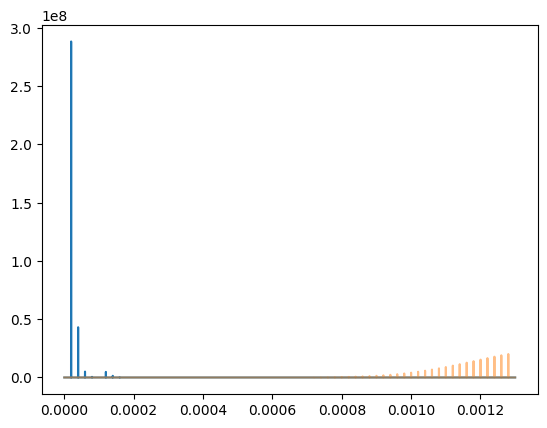

In [17]:
plt.plot(omegalist,sfactortot[100])
plt.plot(omegalist,sfactordiag[1100],alpha=0.5)

# plt.plot(qlist,s_diag_nobin[:,0]+s_diag_nobin[:,1]+s_offdiag_nobin[:,0]+s_offdiag_nobin[:,1])

dR/dq calculation & plotting

In [18]:
dm_length = 200
dmmasslist_4plot = np.array([100,1e3, 40e3, 100e3]) # 10^2 ~ 10^6 keV
omega_threshold = 1e-6 # keV
cross_section = 1e-40 # cm^2


dRdq_result_4plot = []
dRdq_result_incoh_4plot = []
qlist_4plot = []
    
rate_result = np.empty(dm_length)
rate_result_incoh = np.empty(dm_length)
for ind_m, dmmass in enumerate(dmmasslist_4plot):    
    if ind_m%10 == 0: print(f'processing {ind_m}...')
    q_min, q_max = get_q_lim(dmmass, omega_threshold)
    if q_max < q_list_nSite[-1]:
        qlist = q_list_nSite
        dRdq_result = np.empty(len(q_list_nSite))
        dRdq_result_incoh = np.empty(len(q_list_nSite))
        for ind_q, q in enumerate(qlist): 
            rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, sfactortot[ind_q], cross_section)
            dRdq_result[ind_q] = rateCal.get_diff_rate_dRdq()
            rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, sfactordiag[ind_q], cross_section)
            dRdq_result_incoh[ind_q] = rateCal.get_diff_rate_dRdq()
    else: 
        omega_length=3000
        q_length=2200
        qlist = np.concatenate((q_list_nSite, np.linspace(q_list_nSite[-1], q_max, q_length+1)[1:]))
        dRdq_result = np.empty(q_length+len(q_list_nSite))
        dRdq_result_incoh = np.empty(q_length+len(q_list_nSite))
        for ind_q, q in enumerate(q_list_nSite): 
            rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, sfactortot[ind_q], cross_section)
            dRdq_result[ind_q] = rateCal.get_diff_rate_dRdq()
            rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, sfactordiag[ind_q], cross_section)
            dRdq_result_incoh[ind_q] = rateCal.get_diff_rate_dRdq()
        for ind_q, q in enumerate(qlist[len(q_list_nSite):]): 
            omega_max = get_omega_lim(dmmass, q)
            omegalist = np.linspace(omega_threshold,omega_max , omega_length)
            s_factor_ia = get_impulse_approx(q, omegalist, )
            rateCal = RateCalculations(dmmass, q, omegalist, omega_threshold, s_factor_ia, cross_section)
            dRdq_result[ind_q+len(q_list_nSite)] = rateCal.get_diff_rate_dRdq()
            dRdq_result_incoh[ind_q+len(q_list_nSite)] = rateCal.get_diff_rate_dRdq()
    dRdq_result_4plot.append(dRdq_result)
    dRdq_result_incoh_4plot.append(dRdq_result_incoh)
    qlist_4plot.append(qlist)
    # rate_result[ind_m] = sp.integrate.simpson(dRdq_result, qlist) # per kg-year
    # rate_result_incoh[ind_m] = sp.integrate.simpson(dRdq_result_incoh, qlist)

processing 0...


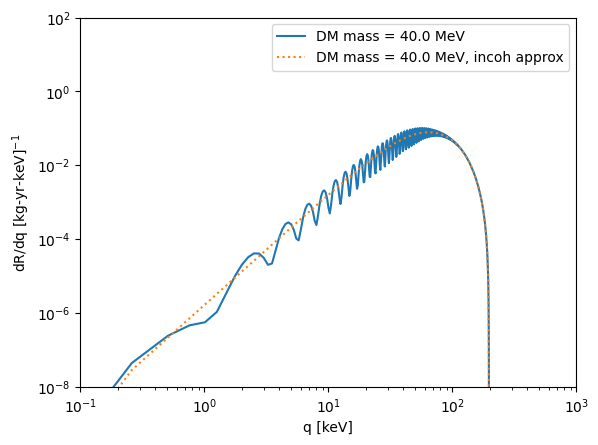

In [20]:
for i in range(2,3):
    plt.plot(qlist_4plot[i], dRdq_result_4plot[i], label=f'DM mass = {dmmasslist_4plot[i]/1e3:.1f} MeV')
for i in range(2,3):
    plt.plot(qlist_4plot[i], dRdq_result_incoh_4plot[i], label=f'DM mass = {dmmasslist_4plot[i]/1e3:.1f} MeV, incoh approx',linestyle=':')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-8, 100)
plt.xlim(0.1,1e3)
plt.xlabel('q [keV]')
plt.ylabel('dR/dq [kg-yr-keV]$^{-1}$')
plt.legend()
plt.show()